# Part 1. Data Processing

## a) Import Dataset

In [ ]:
import numpy as np
import tensorflow as tf
import random

In [ ]:
import torch
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = torch.tensor(x_train).permute(0, 3, 1, 2).float() / 255.0
x_test  = torch.tensor(x_test).permute(0, 3, 1, 2).float() / 255.0
y_train = torch.tensor(y_train).squeeze().long()
y_test  = torch.tensor(y_test).squeeze().long()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: torch.Size([50000, 3, 32, 32])
Training labels: torch.Size([50000])
Test images: torch.Size([10000, 3, 32, 32])
Test labels: torch.Size([10000])


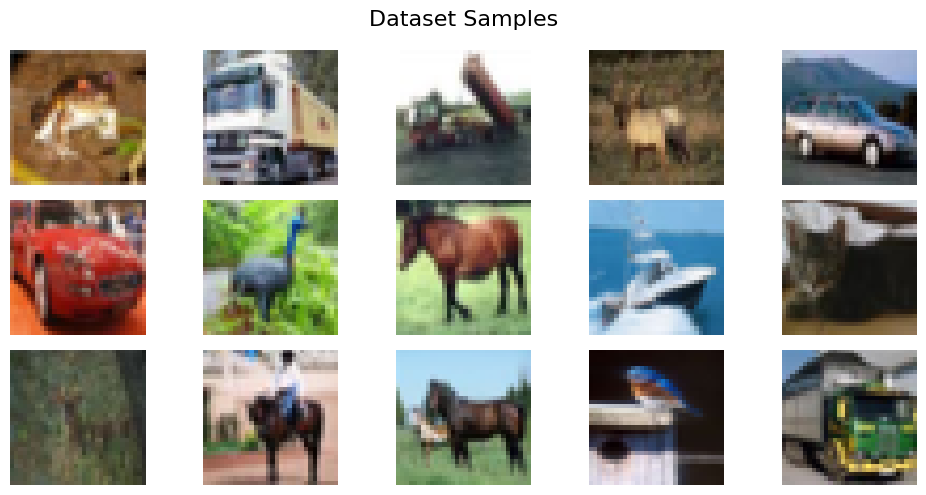

In [ ]:
import matplotlib.pyplot as plt

num_images = 15
plt.figure(figsize=(10,5))

for i in range(num_images):
    img = x_train[i].permute(1,2,0)
    plt.subplot(3, 5, i+1)
    plt.axis('off')
    plt.imshow(img)

plt.suptitle('Dataset Samples', fontsize=16)
plt.tight_layout()
plt.show()

## b) Augment Data with Spurious Features

In [ ]:
def augment_spurious(image, color, size=3):
  img = image.clone()
  color_tensor = torch.tensor(color, dtype=img.dtype, device=img.device).view(-1,1,1)
  img[:, 0:size, 0:size] = color_tensor
  return img

In [ ]:
# images already normalized when loaded in as tensors
colors = {
    0: (1.0,0,0),   # airplane = bright red
    1: (0,1.0,0),   # automobile = bright green
    2: (0,0,1.0),   # bird = bright blue
    3: (1.0,1.0,0), # cat = bright yellow
    4: (1.0,0,1.0), # deer = pink
    5: (0,1.0,1.0), # dog = teal
    6: (0.5,0,0),   # frog = dark red
    7: (0,0.5,0),   # horse = dark green
    8: (0,0,0.5),   # ship = dark blue
    9: (0.5,0.5,0)  # truck = dark yellow
}

Augment % of training data for each class label (change % to see effect on groupDRO)

In [ ]:
np.random.seed(424)

num_classes = 10
augment_ratio = 0.9

# flag to check if image has dot
dot_flag = torch.zeros(len(x_train), dtype=torch.long)

x_train_spurious = x_train.clone()

for i in range(num_classes):
  class_indices = np.where(y_train.numpy() == i)[0]
  num_augment = int(len(class_indices) * augment_ratio)
  random_indices = np.random.choice(class_indices, num_augment, replace=False)

  for idx in random_indices:
    color = colors[y_train[idx].item()]
    x_train_spurious[idx] = augment_spurious(x_train_spurious[idx], color=color)
    dot_flag[idx] = 1

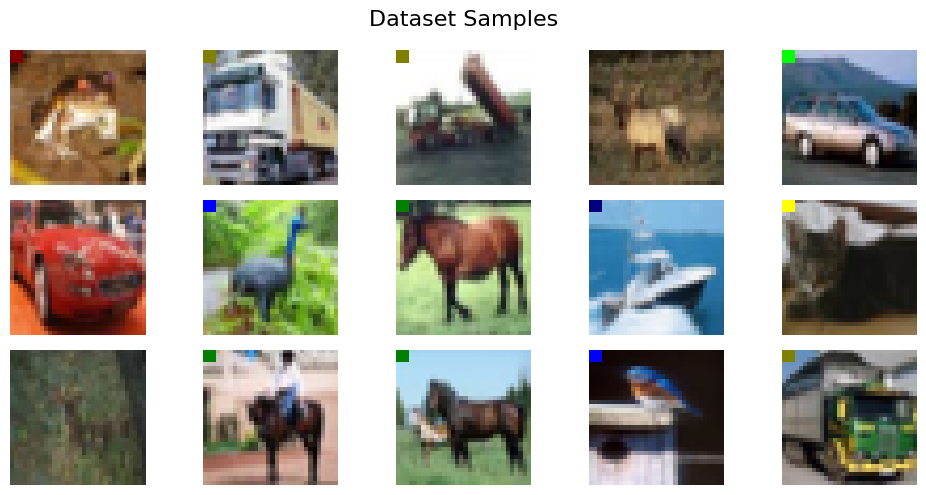

In [ ]:
num_images = 15
plt.figure(figsize=(10,5))

for i in range(num_images):
    img = x_train_spurious[i].permute(1,2,0)
    plt.subplot(3, 5, i+1)
    plt.axis('off')
    plt.imshow(img)

plt.suptitle('Dataset Samples', fontsize=16)
plt.tight_layout()
plt.show()

Apply colors for all data in biaset test set

In [ ]:
x_test_spurious = x_test.clone()
for idx in range(len(x_test_spurious)):
  color = colors[y_test[idx].item()]
  x_test_spurious[idx] = augment_spurious(x_test_spurious[idx], color=color)

Apply reversed colors list for all data in anti-biased test set

In [ ]:
reversed_colors = list(colors.values())[::-1]
x_test_antibiased = x_test.clone()

for idx in range(len(x_test_antibiased)):
  color = reversed_colors[y_test[idx].item()]
  x_test_antibiased[idx] = augment_spurious(x_test_antibiased[idx], color=color)

## c) Prepare DataLoaders

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128

dot_flag_bias = torch.ones(len(x_test_spurious), dtype=torch.long)
dot_flag_nobias = torch.zeros(len(x_test), dtype=torch.long)
dot_flag_antibias = torch.ones(len(x_test_spurious), dtype=torch.long)

train_dataset = TensorDataset(x_train_spurious, y_train, dot_flag)
test_nobias_dataset = TensorDataset(x_test, y_test, dot_flag_nobias)
test_bias_dataset   = TensorDataset(x_test_spurious, y_test, dot_flag_bias)
test_antibias_dataset = TensorDataset(x_test_antibiased, y_test, dot_flag_antibias)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_nobias_loader  = DataLoader(test_nobias_dataset, batch_size=batch_size)
test_bias_loader  = DataLoader(test_bias_dataset, batch_size=batch_size)
test_antibias_loader  = DataLoader(test_antibias_dataset, batch_size=batch_size)

# Part 2. Implement Models

## a) Model Architecture

### i) Baseline ERM

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) #in_channels, out_chanels, kernel_size, padding
        self.pool = nn.MaxPool2d(2, 2) #kernel_size, stride
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128*4*4, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

### ii) GroupDRO

In [ ]:
class GroupDROCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1   = nn.Linear(128*4*4, 64)
        self.fc2   = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## b) Train Model

### Accuracy Function

In [ ]:
def get_accuracy(model, data_loader,max_batches=None):
    model.eval()
    correct = 0
    total = 0
    n = 0

    with torch.no_grad():
        for images, labels, _ in data_loader:
            if max_batches is not None and n >= max_batches:
                break
            n += 1

            if torch.cuda.is_available():
                images = images.cuda()
                labels = labels.cuda()
                model.cuda()

            output = model(images)
            preds = output.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct/total

### ERM Training loop function

In [ ]:
def train(model, train, epochs = 1, learning_rate = 1e-3, max_iters = 50):
  print("start")

  torch.manual_seed(424)

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  iters, losses, train_acc = [], [], []
  n = 0 # the number of iterations
  for epoch in range(epochs):
      epoch_losses = []
      n=0
      for images, labels,_ in train_loader:
          if max_iters is not None and n >= max_iters:
              break

          if torch.cuda.is_available():
            images = images.cuda()
            labels = labels.cuda()
            model.cuda()

          model.train()
          optimizer.zero_grad()
          output = model(images)

          loss = criterion(output, labels)
          loss.backward()
          optimizer.step()

          iters.append(n)
          epoch_losses.append(loss.item())
          n += 1

      epoch_acc = get_accuracy(model, train_loader, max_batches=5)
      train_acc.append(epoch_acc)
      epoch_loss = sum(epoch_losses) / len(epoch_losses)
      losses.append(epoch_loss)
      print(f"Epoch {epoch+1}/{epochs} - Accuracy: {epoch_acc:.4f} - Avg Loss: {epoch_loss:.4f}")


  # Plot the graphs

  # Accuracy Plot
  plt.title("Training Curve")
  plt.plot(range(1, epochs+1), train_acc, label='Training')
  plt.xlabel('Iterations')
  plt.ylabel('Accuracy')
  plt.show()

  # Loss Plot
  plt.title('Training Curve')
  plt.plot(range(1, epochs+1), losses, label='Training')
  plt.xlabel('Iterations')
  plt.ylabel('Loss')
  plt.show()

  print("Final Training Accuracy: {}".format(train_acc[-1]))
  return train_acc[-1]

start
Epoch 1/20 - Accuracy: 0.4234 - Avg Loss: 2.1069
Epoch 2/20 - Accuracy: 0.7688 - Avg Loss: 1.3572
Epoch 3/20 - Accuracy: 0.8547 - Avg Loss: 0.9135
Epoch 4/20 - Accuracy: 0.8672 - Avg Loss: 0.6369
Epoch 5/20 - Accuracy: 0.8797 - Avg Loss: 0.4991
Epoch 6/20 - Accuracy: 0.9156 - Avg Loss: 0.4062
Epoch 7/20 - Accuracy: 0.9469 - Avg Loss: 0.3456
Epoch 8/20 - Accuracy: 0.9125 - Avg Loss: 0.3216
Epoch 9/20 - Accuracy: 0.9172 - Avg Loss: 0.2928
Epoch 10/20 - Accuracy: 0.9313 - Avg Loss: 0.2646
Epoch 11/20 - Accuracy: 0.9391 - Avg Loss: 0.2314
Epoch 12/20 - Accuracy: 0.9328 - Avg Loss: 0.2303
Epoch 13/20 - Accuracy: 0.9297 - Avg Loss: 0.2240
Epoch 14/20 - Accuracy: 0.9484 - Avg Loss: 0.2205
Epoch 15/20 - Accuracy: 0.9500 - Avg Loss: 0.2338
Epoch 16/20 - Accuracy: 0.9375 - Avg Loss: 0.2049
Epoch 17/20 - Accuracy: 0.9078 - Avg Loss: 0.2109
Epoch 18/20 - Accuracy: 0.9406 - Avg Loss: 0.2158
Epoch 19/20 - Accuracy: 0.9531 - Avg Loss: 0.2302
Epoch 20/20 - Accuracy: 0.9375 - Avg Loss: 0.2078


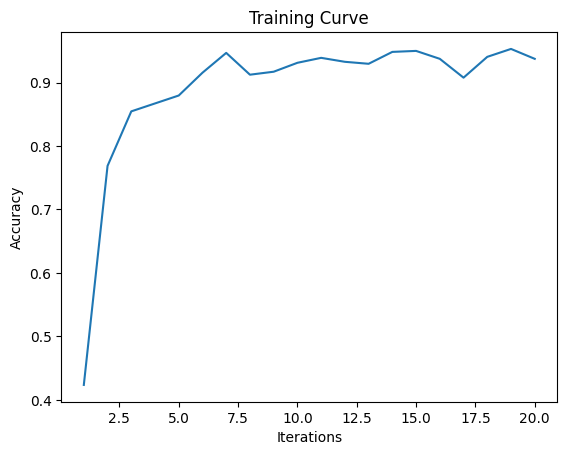

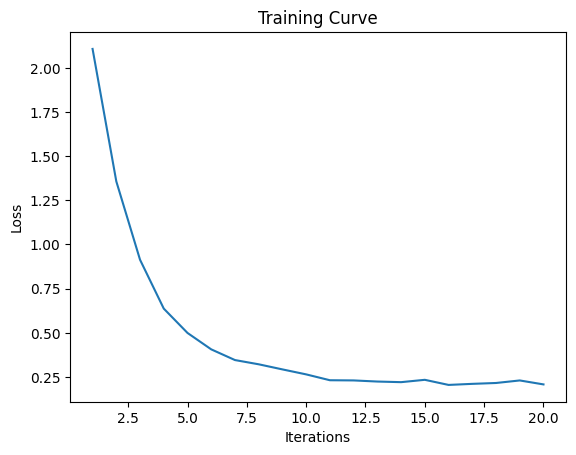

Final Training Accuracy: 0.9375


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)
#model = BaselineCNN()
train_acc = train(model, train_loader, epochs=20, learning_rate=1e-3)

### GroupDRO Training Function

In [ ]:
def train_groupdro(model, train_loader, epochs=20, learning_rate=1e-3,
                   eta_q=0.01, weight_decay=1e-4, max_iters=None):
    print("start GroupDRO training")

    torch.manual_seed(424)
    device = next(model.parameters()).device

    criterion = nn.CrossEntropyLoss(reduction='none')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=weight_decay)

    # groups divided based on both class and dot flag boolean
    num_groups = num_classes * 2

    # Initialize uniform group weights (one per class)
    q = torch.ones(num_groups, device=device) / num_groups

    train_acc_history = []
    loss_history      = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        n = 0

        for images, labels, dot_flag in train_loader:
            if max_iters is not None and n >= max_iters:
                break

            images = images.to(device)
            labels = labels.to(device)
            dot_flag = dot_flag.to(device)

            groups = labels * 2 + dot_flag

            optimizer.zero_grad()
            output = model(images)

            # Per-sample losses
            per_sample_loss = criterion(output, labels)  # shape: (batch,)

            # Compute per-group average loss and update q
            group_losses = torch.zeros(num_groups, device=device)
            group_counts = torch.zeros(num_groups, device=device)

            for g in range(num_groups):
                mask = (labels == g)
                if mask.sum() > 0:
                    group_losses[g] = per_sample_loss[mask].mean()
                    group_counts[g] = 1 # marks if appears in batch

            # Update group weights: exponentiated gradient ascent on q
            q = q * torch.exp(eta_q * group_losses.detach() * group_counts)
            q = q / q.sum()  # renormalize to probability simplex

            # Weighted robust loss
            robust_loss = (q * group_losses).sum()

            robust_loss.backward()
            optimizer.step()

            epoch_losses.append(robust_loss.item())
            n += 1

        epoch_loss = sum(epoch_losses) / len(epoch_losses)
        epoch_acc  = get_accuracy(model, train_loader, max_batches=5)
        train_acc_history.append(epoch_acc)
        loss_history.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - Accuracy: {epoch_acc:.4f} "
              f"- Avg Robust Loss: {epoch_loss:.4f} "
              f"- Max Group Weight: {q.max().item():.4f}")

    # Accuracy Plot
    plt.title("GroupDRO Training Curve - Accuracy")
    plt.plot(range(1, epochs+1), train_acc_history, label='Training')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss Plot
    plt.title("GroupDRO Training Curve - Robust Loss")
    plt.plot(range(1, epochs+1), loss_history, label='Robust Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f"Final Training Accuracy: {train_acc_history[-1]:.4f}")
    return train_acc_history[-1]

start GroupDRO training
Epoch 1/20 - Accuracy: 0.9219 - Avg Robust Loss: 0.5207 - Max Group Weight: 0.1130
Epoch 2/20 - Accuracy: 0.9563 - Avg Robust Loss: 0.2163 - Max Group Weight: 0.1159
Epoch 3/20 - Accuracy: 0.9500 - Avg Robust Loss: 0.1838 - Max Group Weight: 0.1263
Epoch 4/20 - Accuracy: 0.9406 - Avg Robust Loss: 0.1728 - Max Group Weight: 0.1315
Epoch 5/20 - Accuracy: 0.9297 - Avg Robust Loss: 0.1616 - Max Group Weight: 0.1364
Epoch 6/20 - Accuracy: 0.9516 - Avg Robust Loss: 0.1523 - Max Group Weight: 0.1405
Epoch 7/20 - Accuracy: 0.9625 - Avg Robust Loss: 0.1441 - Max Group Weight: 0.1401
Epoch 8/20 - Accuracy: 0.9625 - Avg Robust Loss: 0.1373 - Max Group Weight: 0.1422
Epoch 9/20 - Accuracy: 0.9453 - Avg Robust Loss: 0.1305 - Max Group Weight: 0.1435
Epoch 10/20 - Accuracy: 0.9516 - Avg Robust Loss: 0.1221 - Max Group Weight: 0.1448
Epoch 11/20 - Accuracy: 0.9609 - Avg Robust Loss: 0.1172 - Max Group Weight: 0.1451
Epoch 12/20 - Accuracy: 0.9812 - Avg Robust Loss: 0.1122 - Ma

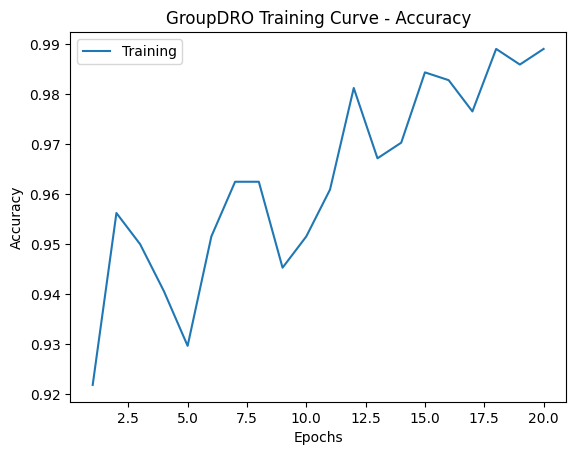

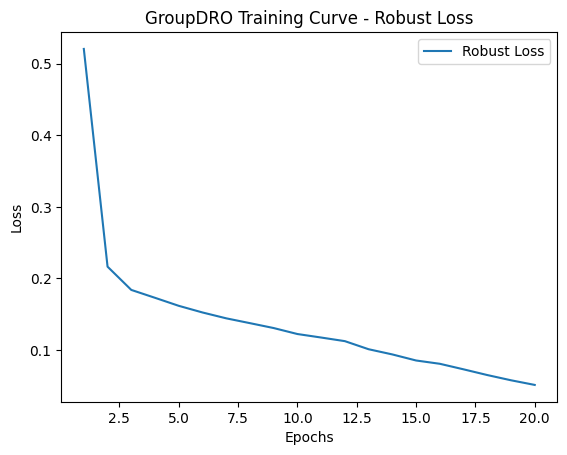

Final Training Accuracy: 0.9891


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dro  = GroupDROCNN().to(device)

train_acc = train_groupdro(model_dro, train_loader,epochs=20,learning_rate=1e-3,eta_q=0.01,weight_decay=1e-4)

# Part 3. Test Models

## a) Baseline ERM

In [ ]:
acc_nobias = get_accuracy(model, test_nobias_loader)
acc_bias = get_accuracy(model, test_bias_loader)
acc_antibias = get_accuracy(model, test_antibias_loader)

print(f"Test Accuracy (No Bias): {acc_nobias:.4f}")
print(f"Test Accuracy (Bias): {acc_bias:.4f}")
print(f"Test Accuracy (Anti-Bias): {acc_antibias:.4f}")

Test Accuracy (No Bias): 0.3580
Test Accuracy (Bias): 0.9999
Test Accuracy (Anti-Bias): 0.0002


## b) GroupDRO

In [ ]:
acc_nobias  = get_accuracy(model_dro, test_nobias_loader)
acc_bias    = get_accuracy(model_dro, test_bias_loader)
acc_antibias = get_accuracy(model_dro, test_antibias_loader)

print(f"Test Accuracy (No Bias):   {acc_nobias:.4f}")
print(f"Test Accuracy (Bias):      {acc_bias:.4f}")
print(f"Test Accuracy (Anti-Bias): {acc_antibias:.4f}")

Test Accuracy (No Bias):   0.5458
Test Accuracy (Bias):      0.9996
Test Accuracy (Anti-Bias): 0.0044


# Part 4. Data Visualization

## a) Saliency Map Functions

In [ ]:
def compute_saliency(img, label, model):
  # ensure consistent cpu/gpu usage
  device = next(model.parameters()).device
  img = img.to(device).float()

  img = img.unsqueeze(0)
  img.requires_grad = True

  # Forward pass
  output = model(img)
  score = output[0, int(label)]

  # Backpropagation
  model.zero_grad()
  score.backward()

  # Saliency Calculation
  saliency, _ = torch.max(img.grad.abs(), dim=1)
  return saliency.squeeze().cpu()

In [ ]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def plot_average_saliency(model, test_loader, classes, device=None):
    model.eval()
    saliency_maps = {}
    device = next(model.parameters()).device if device is None else device


    for idx, class_name in enumerate(classes):
        # intialize saliency value for single class
        saliency_sum = torch.zeros((32,32))
        count = 0

        # add saliency values of each image belong to class
        for imgs, labels,_ in test_loader:
            for img, label in zip(imgs, labels):
                if int(label) == idx:
                    saliency = compute_saliency(img, idx, model)
                    saliency_sum += saliency
                    count += 1

        # calculate average saliency for class
        saliency_maps[class_name] = saliency_sum / count

    # Plot maps
    fig, axes = plt.subplots(2,5, figsize=(15,6))
    axes = axes.flatten()

    for idx, class_name in enumerate(classes):
        axes[idx].imshow(saliency_maps[class_name], cmap='hot')
        axes[idx].set_title(class_name)
        axes[idx].axis('off')

    plt.suptitle("Average Saliency Maps")
    plt.show()

    return saliency_maps

## b) Average Saliency Map - ERM



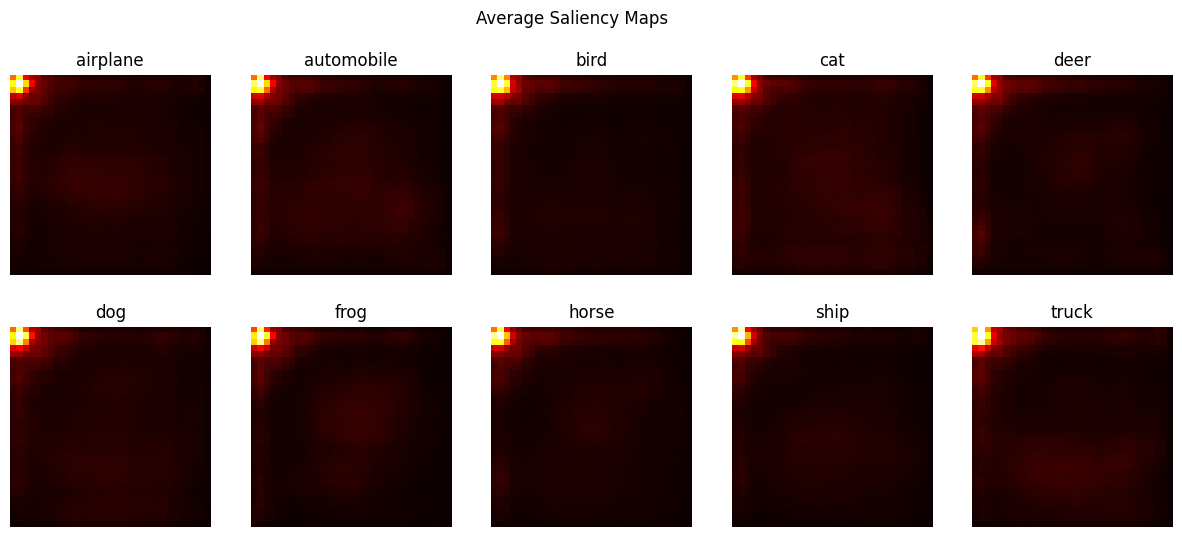

In [ ]:
baseline_saliency = plot_average_saliency(model, test_nobias_loader, classes)

## c) Average Saliency Map - GroupDRO

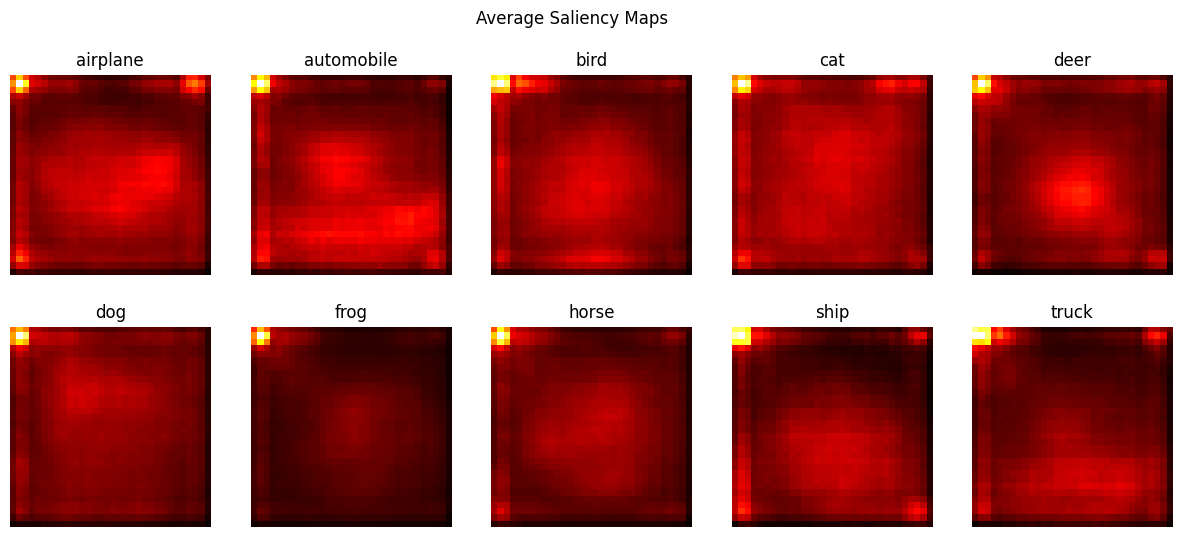

In [ ]:
groupdro_saliency = plot_average_saliency(model_dro, test_nobias_loader, classes)